**Problem Statement:**
Google Play Store team is about to launch a new feature wherein, certain apps that are promising are boosted in visibility. The boost will
manifest in multiple ways including higher priority in recommendations sections (“Similar apps”, “You might also like”, “New and updated
games”). These will also get a boost in search results visibility. This feature will help bring more attention to newer apps that have the
potential.


**Analysis to be done:**
The problem is to identify the apps that are going to be good for Google to promote. App ratings, which are provided by the customers,
are always great indicators of the goodness of the app. The problem reduces to: predict which apps will have high ratings.

**Data Dictionary:**

Variables Description

- App: Application name

- Category: Category to which the app belongs

- Rating: Overall user rating of the app

- Reviews: Number of user reviews for the app

- Size: Size of the app

- Installs: Number of user downloads/installs for the app

- Type: Paid or Free

- Price: Price of the app

- Content: Rating Age group the app is targeted at - Children / Mature 21+ / Adult

- Genres: An app can belong to multiple genres (apart from its main category). For example, a musical family game will belong to Music, Game, Family genres

- Last: Updated Date when the app was last updated on Play Store

- Current Ver: Current version of the app available on Play Store

- Android Ver: Minimum required Android version

#### 1) Importing Necessary Libraries:

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV,  ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import TransformerMixin, BaseEstimator

#### 2) Importing Data:

In [60]:
df = pd.read_csv('googleplaystore.csv')

In [61]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content_Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art_&_Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art_&_Design_Pretend_Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art_&_Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art_&_Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art_&_Design_Creativity,"June 20, 2018",1.1,4.4 and up


In [62]:
df.shape

(10841, 13)

#### 3) Data Cleaning:

In [63]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [64]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content_Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

- Columns like Reviews, Size, Installs, Price should be numeric but are stored as Object type.

##### 1) Handling Wrong Data Types and Cleaning Data:

In [65]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content_Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art_&_Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art_&_Design_Pretend_Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art_&_Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art_&_Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art_&_Design_Creativity,"June 20, 2018",1.1,4.4 and up


###### 1) Dropping Unnecesaary Columns:

- App: Name of the application is not a feature and is unique for all records, should be deleted.
- Current Ver: Current Version of the Application, not useful in analysis, should Be dropped.
- Android Ver: Required Android Version, not necessary for model building.

In [66]:
df.drop(['App','Current Ver', 'Android Ver'], axis= 1, inplace= True)

In [67]:
df.head()

,Category,Rating,Reviews,Size,Installs,Type,Price,Content_Rating,Genres,Last Updated
0,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art_&_Design,"January 7, 2018"
1,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art_&_Design_Pretend_Play,"January 15, 2018"
2,ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art_&_Design,"August 1, 2018"
3,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art_&_Design,"June 8, 2018"
4,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art_&_Design_Creativity,"June 20, 2018"


###### 2) Transforming Date and Android Version Columns:

In [68]:
df['Days Since Update'] = (pd.to_datetime(date.today()) - pd.to_datetime(df['Last Updated'], errors= 'coerce')).dt.days

In [70]:
df.drop('Last Updated', axis= 1, inplace= True)

In [71]:
df.head()

,Category,Rating,Reviews,Size,Installs,Type,Price,Content_Rating,Genres,Days Since Update
0,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art_&_Design,2854.0
1,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art_&_Design_Pretend_Play,2846.0
2,ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art_&_Design,2648.0
3,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art_&_Design,2702.0
4,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art_&_Design_Creativity,2690.0


###### 3) Category:

In [72]:
df['Category'].value_counts()

Category
FAMILY                 1972
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
WEATHER                  82
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

In [75]:
len(df['Category'].unique())

34

- Category has a moderately high Cardinality with 34 categories.
- We can use One Hot Encoding here.
- Note: Different methods should be considered is Cardinality increases.

In [77]:
# Preprocessing Transformer:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category'])
])

###### 4) Rating:

- Rating is Out Target Variable, so no need to do any Preprocessing ot Transformation.

In [83]:
df['Rating'].isna().sum()

np.int64(1474)

- Rating has 1474 Missing Values.
- As Rating is Target Variable, we shouldn't Impute Missing Values.
- Two Ways here are:
    - Drop Records with Rating Value Missing.
    - Separate Records with Missing Rating into different Dataframe, to be used as Test Data after Model Building.
- For now, we are dropping Records with Missing Rating Value.

In [85]:
df = df.dropna(subset= ['Rating']).reset_index(drop= True)

###### 5) Reviews:

In [88]:
df['Reviews']

0          159
1          967
2        87510
3       215644
4          967
         ...  
9362         7
9363        38
9364         4
9365       114
9366    398307
Name: Reviews, Length: 9367, dtype: object

In [90]:
# df['Reviews'].astype('int')

- Looks like some of the values in Reviews has 'M' or 'k' attached to them for Millions or Thousands, that's why the Column Data Type is Object.

In [92]:
# Function to Clean Reviews Column:

def clean_reviews(col):
    """
    Takes in whole Dataframe Column (Series or Numpy Array) as Input to Clean.
    """
    def parse_review(value):
        """
        Takes in a Single Value at time to process and clean.
        """
        if pd.isna(value):
            return np.nan

        value = str(value).strip()
        
        try:
            if value.endswith('B'):
                return float(value[:-1]) * 1000000000
            elif value.endswith('M'):
                return float(value[:-1]) * 1000000
            elif value.endswith('k'):
                return float(value[:-1]) * 1000
            else:
                return float(value)
        except:
            return np.nan

    return col.apply(parse_review)

In [130]:
review_cleaner = FunctionTransformer(clean_reviews)

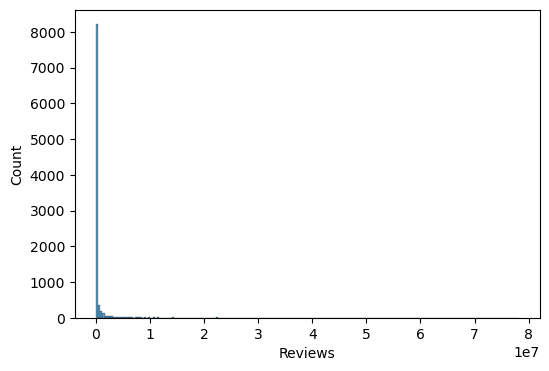

In [139]:
# Checking Distribution of Reviews:

plt.figure(figsize= (6,4))
sns.histplot(clean_reviews(df['Reviews']))
plt.show()

- We will need to Apply Log Transformation here to make the Distribution Normal.

In [131]:
# Pipleline for Preprocessing Steps on Reviews:

review_pipeline = Pipeline([
    ('clean', review_cleaner),
    ('transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

In [125]:
# Updating Preprocessor:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category']),
    ('Reviews', review_pipeline, ['Review'])
])

###### 6) Size:

In [98]:
df['Size']

0                      19M
1                      14M
2                     8.7M
3                      25M
4                     2.8M
               ...        
9362                  2.6M
9363                   53M
9364                  3.6M
9365    Varies with device
9366                   19M
Name: Size, Length: 9367, dtype: object

In [99]:
df['Size'].value_counts()

Size
Varies with device    1637
14M                    166
12M                    161
11M                    160
15M                    159
                      ... 
383k                     1
454k                     1
812k                     1
442k                     1
619k                     1
Name: count, Length: 415, dtype: int64

- We will replace 'M', 'k' here with 1000000 and 1000.
- We will replace Varies with device to NaN.

In [103]:
# Function to Clean Size Column:

def clean_size(col):
    """
    Takes in whole Dataframe Column (Series or Numpy Array) as Input to Clean.
    """
    def parse_size(value):
        """
        Takes in a Single Value at time to process and clean.
        """
        if pd.isna(value):
            return np.nan

        value = str(value).strip()

        if value.lower() == 'varies with device':
            return np.nan

        try:
            if value.endswith('G'):
                return float(value[:-1]) * 1000000000
            elif value.endswith('M'):
                return float(value[:-1]) * 1000000
            elif value.endswith('k'):
                return float(value[:-1]) * 1000
            else:
                return float(value)
        except:
            return np.nan
    
    return col.apply(parse_size)

In [112]:
size_cleaner = FunctionTransformer(clean_size)

- We will also have to deal with NaN values that above Transformation creates inplace of 'Varies with Device' values.
- We will fill in those missing values with Category wise Median size for each app.

In [118]:
class GroupWiseMedianImputer(BaseEstimator, TransformerMixin):

    def __init__(self, group_col, target_col):
        self.group_col = group_col
        self.target_col = target_col
        self.group_medians = None
        self.global_median = None

    def fit(self, X, y= None):
        data = pd.DataFrame(X, columns= [self.group_col, self.target_col])
        self.group_medians = data.groupby(self.group_col)[self.target_col].median()
        self.global_median = data[self.target_col].median()
        return self

    def transform(self, X):
        data = pd.DataFrame(X, columns= [self.group_col, self.target_col])

        def impute_row(row):
            value = row[self.target_col]
            if pd.isna(value):
                group = row[self.group_col]
                group_median = self.group_medians.get(group, np.nan)
                # Fallback to global median if group median is NaN
                if pd.isna(group_median):
                    return self.global_median
                return group_median
            return value

        data[self.target_col] = data.apply(impute_row, axis=1)
        
        return data[[self.target_col]].values        

In [111]:
size_imputer = GroupWiseMedianImputer(group_col= 'Category', target_col= 'Size')

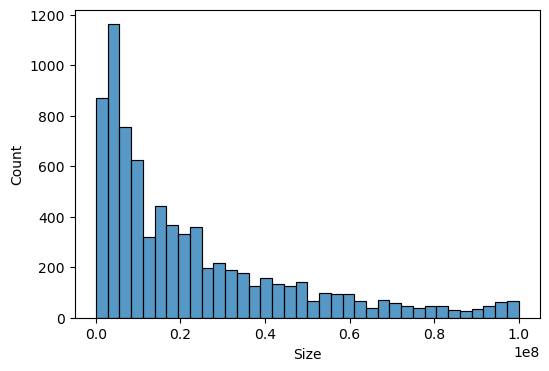

In [146]:
plt.figure(figsize= (6,4))
sns.histplot(clean_reviews(df['Size']))
plt.show()

- Now, Size column has multiple preprocessing Steps to follow:
    - Data Cleaning (Replacing 'M','k','Varies with Device').
    - Missing Value Imputation.
    - Cube Root Transformation.
- We will create a Pipeline of preprocessing steps for Size and then integrate it with main Column Transformer.

In [155]:
size_pipeline = Pipeline([
    ('Cleaning', size_cleaner),
    ('imputer', size_imputer),
    ('transform', FunctionTransformer(np.cbrt)),
    ('scaler', StandardScaler())
])

In [156]:
# Updating Preprocessor:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category']),
    ('Reviews', review_pipeline, ['Review']),
    ('Size', size_pipeline, ['Category', 'Size'])
])

###### 7) Installs:

In [116]:
df['Installs']

0           10,000+
1          500,000+
2        5,000,000+
3       50,000,000+
4          100,000+
           ...     
9362           500+
9363         5,000+
9364           100+
9365         1,000+
9366    10,000,000+
Name: Installs, Length: 9367, dtype: object

In [117]:
df['Installs'].value_counts()

Installs
1,000,000+        1577
10,000,000+       1252
100,000+          1150
10,000+           1010
5,000,000+         752
1,000+             713
500,000+           538
50,000+            467
5,000+             432
100,000,000+       409
100+               309
50,000,000+        289
500+               201
500,000,000+        72
10+                 69
1,000,000,000+      58
50+                 56
5+                   9
1+                   3
Free                 1
Name: count, dtype: int64

- Value in Isntalls have invalid characters like '+' or ',' in it.
- One value is 'Free'.

In [121]:
# Fucntion to Clean Installs Column:

def clean_installs(col):
    def parse_inastall(value):
        if pd.isna(value):
            return pd.nan

        value = str(value).strip()

        if value.lower() in ['free', 'nan', 'none']:
            return np.nan

        cleaned_value = value.replace('+','').replace(',','')

        try:
            return int(cleaned_value)
        except:
            return np.nan

    return col.apply(parse_inastall)

In [126]:
installs_cleaner = FunctionTransformer(clean_installs)

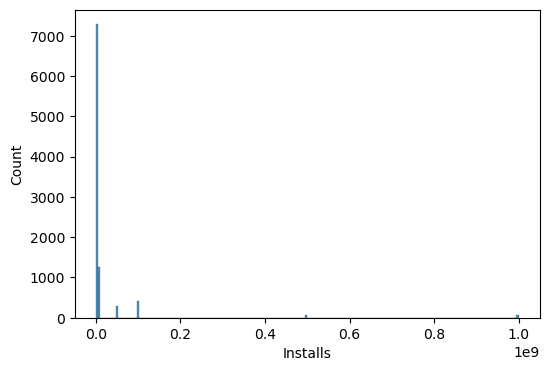

In [158]:
plt.figure(figsize= (6,4))
sns.histplot(clean_installs(df['Installs']))
plt.show()

- We will also have to take care of Missing Values we created by above step (replacing 'free' with NaN).
- We will also have to scale the Installs feature.
- Log Transformation.

In [168]:
installs_pipeline = Pipeline([
    ('clean', installs_cleaner),
    ('impute', SimpleImputer(strategy= 'median')),
    ('transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

In [169]:
# Updating Preprocessor:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category']),
    ('Reviews', review_pipeline, ['Review']),
    ('Size', size_pipeline, ['Category', 'Size']),
    ('Installs', installs_pipeline, ['Installs'])
])

###### 8) Type:

In [137]:
df['Type']

0       Free
1       Free
2       Free
3       Free
4       Free
        ... 
9362    Free
9363    Free
9364    Free
9365    Free
9366    Free
Name: Type, Length: 9367, dtype: object

In [138]:
df['Type'].value_counts()

Type
Free    8719
Paid     647
0          1
Name: count, dtype: int64